# Feature Engineering & Scoring for EduTrack

## Overview
This notebook covers:
- Feature engineering for institutional metrics
- Performance scoring algorithms
- Risk assessment calculations
- Feature importance analysis
- Output preparation for modeling

In [1]:
import sys
import os

# Add project root to path (notebooks are in /notebooks subdirectory)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load & Prepare Data

In [2]:
# Import modules
from src.data_processing.transformer import FeatureEngineer

# Load cleaned data
data_path = os.path.join(project_root, 'data/processed/college_data_cleaned.csv')
df = pd.read_csv(data_path)

print(f"Loaded {len(df)} institutions")
print(f"Columns: {len(df.columns)}")

Loaded 4831 institutions
Columns: 20


## 2. Feature Engineering

In [4]:
# Feature Engineering
engineer = FeatureEngineer()
df_features = engineer.engineer_features(df)

print(f"Featured dataset shape: {df_features.shape}")
print(f"New features created: {set(df_features.columns) - set(df.columns)}")
print(f"\nSample engineered features:")
print(df_features[['Student_Faculty_Ratio', 'Faculty_Adequacy', 'Infrastructure_Quality']].head())

Featured dataset shape: (4831, 31)
New features created: {'Fee_Category', 'High_Compliance_Risk', 'Faculty_Adequacy', 'Infrastructure_Quality', 'Document_Completeness_Pct', 'Infrastructure_Per_Student', 'Student_Faculty_Ratio', 'Overall_Performance_Score', 'Financial_Efficiency', 'Placement_Category', 'DSS_Category'}

Sample engineered features:
   Student_Faculty_Ratio  Faculty_Adequacy  Infrastructure_Quality
0              14.623100         90.251266                    20.0
1               5.578125         96.281250                    20.0
2              37.217822         72.782178                    20.0
3              15.866197         89.422535                    20.0
4              20.247059         86.501961                    20.0


## 3. Student-Faculty Ratio Analysis

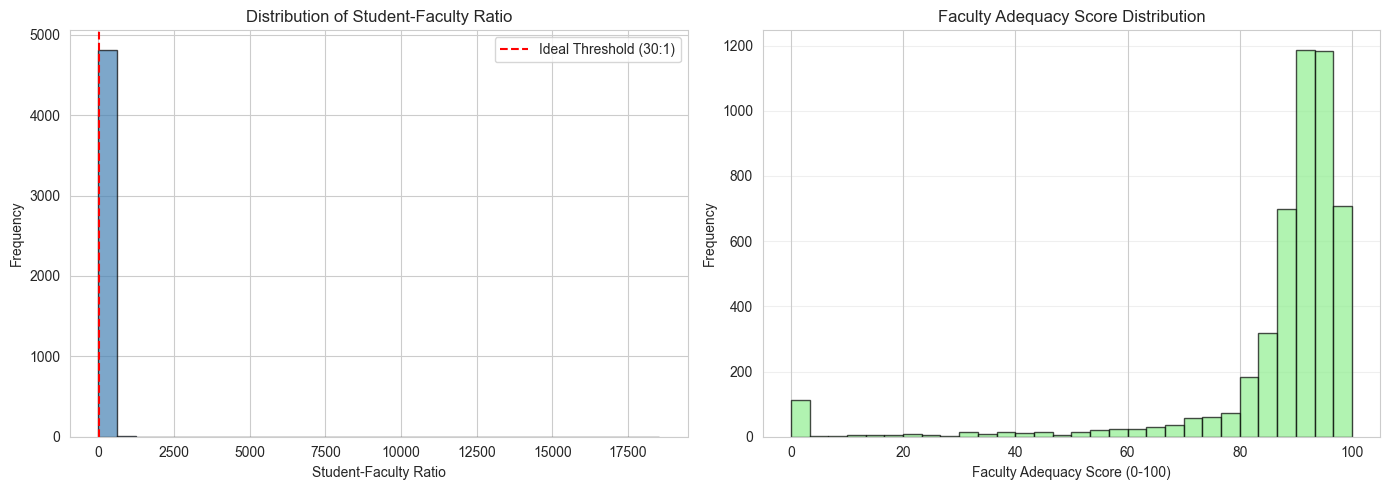

Student-Faculty Ratio:
  Mean: 25.62
  Median: 11.94
  Good Range (20-30): 503 institutions


In [5]:
# Analyze student-faculty ratio feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df_features['Student_Faculty_Ratio'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(30, color='red', linestyle='--', label='Ideal Threshold (30:1)')
axes[0].set_xlabel('Student-Faculty Ratio')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Student-Faculty Ratio')
axes[0].legend()

# Faculty Adequacy Score
axes[1].hist(df_features['Faculty_Adequacy'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Faculty Adequacy Score (0-100)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Faculty Adequacy Score Distribution')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Student-Faculty Ratio:")
print(f"  Mean: {df_features['Student_Faculty_Ratio'].mean():.2f}")
print(f"  Median: {df_features['Student_Faculty_Ratio'].median():.2f}")
print(f"  Good Range (20-30): {((df_features['Student_Faculty_Ratio'] >= 20) & (df_features['Student_Faculty_Ratio'] <= 30)).sum()} institutions")

## 4. Infrastructure Quality Analysis

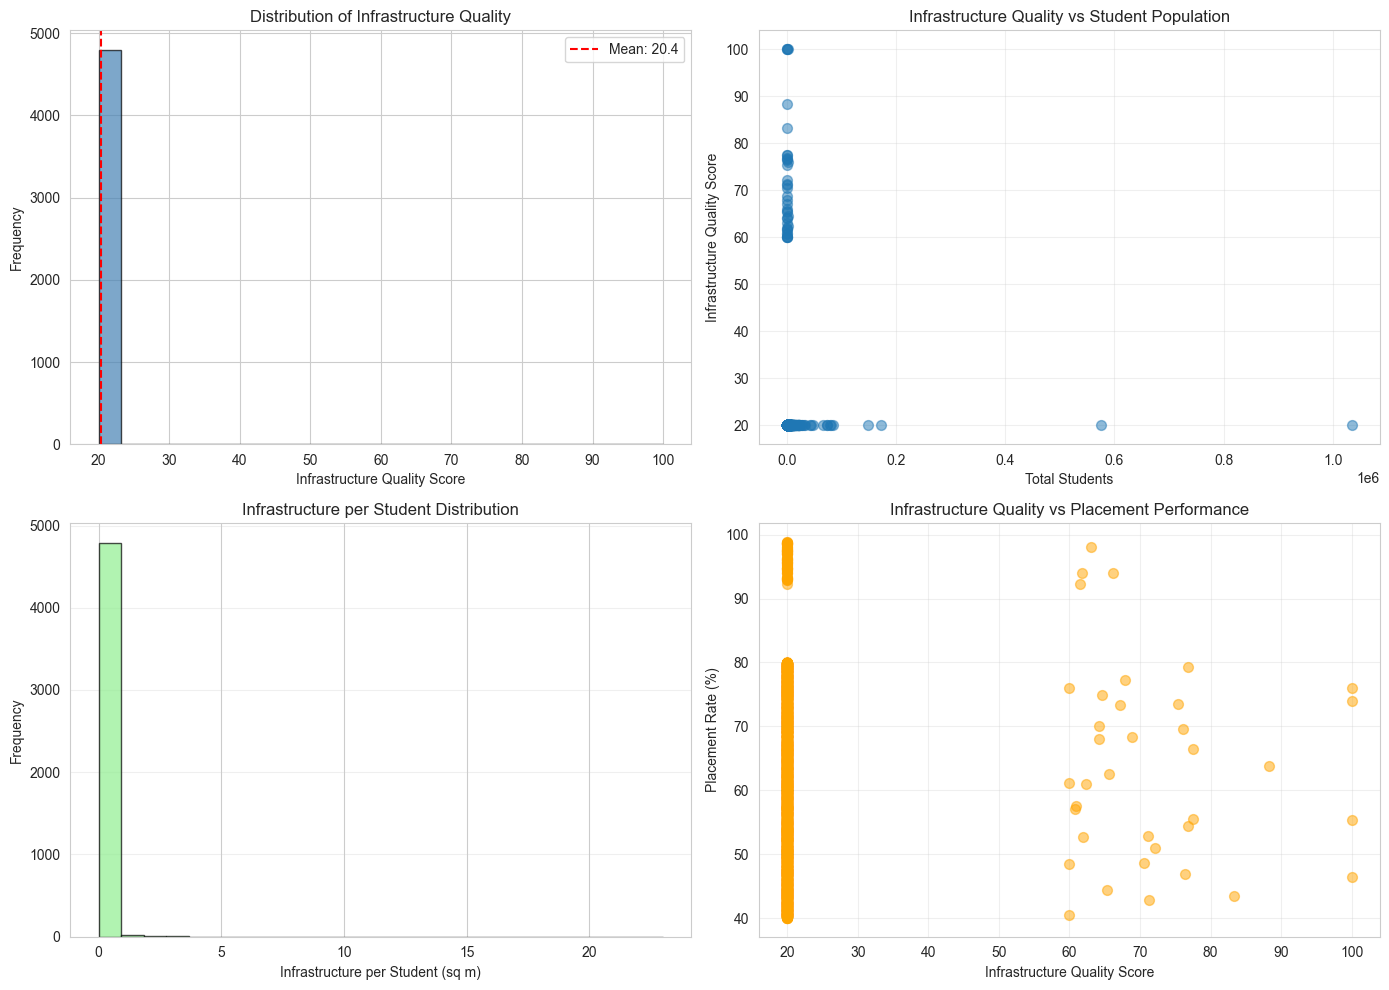

Infrastructure Quality Statistics:
  Mean Quality Score: 20.40
  Mean per Student: 0.08 sq m
  Good Quality (≥70): 17 institutions


In [6]:
# Analyze infrastructure quality
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Infrastructure Quality Score
axes[0, 0].hist(df_features['Infrastructure_Quality'], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_features['Infrastructure_Quality'].mean(), color='red', linestyle='--', 
                    label=f"Mean: {df_features['Infrastructure_Quality'].mean():.1f}")
axes[0, 0].set_xlabel('Infrastructure Quality Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Infrastructure Quality')
axes[0, 0].legend()

# Infrastructure vs Student Count
axes[0, 1].scatter(df_features['Total_Students'], df_features['Infrastructure_Quality'], alpha=0.5, s=50)
axes[0, 1].set_xlabel('Total Students')
axes[0, 1].set_ylabel('Infrastructure Quality Score')
axes[0, 1].set_title('Infrastructure Quality vs Student Population')
axes[0, 1].grid(True, alpha=0.3)

# Infrastructure per Student
axes[1, 0].hist(df_features['Infrastructure_Per_Student'], bins=25, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Infrastructure per Student (sq m)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Infrastructure per Student Distribution')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Infrastructure vs Placement
axes[1, 1].scatter(df_features['Infrastructure_Quality'], df_features['Placement_Rate'], alpha=0.5, s=50, color='orange')
axes[1, 1].set_xlabel('Infrastructure Quality Score')
axes[1, 1].set_ylabel('Placement Rate (%)')
axes[1, 1].set_title('Infrastructure Quality vs Placement Performance')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Infrastructure Quality Statistics:")
print(f"  Mean Quality Score: {df_features['Infrastructure_Quality'].mean():.2f}")
print(f"  Mean per Student: {df_features['Infrastructure_Per_Student'].mean():.2f} sq m")
print(f"  Good Quality (≥70): {(df_features['Infrastructure_Quality'] >= 70).sum()} institutions")

## 5. Compliance & Document Analysis

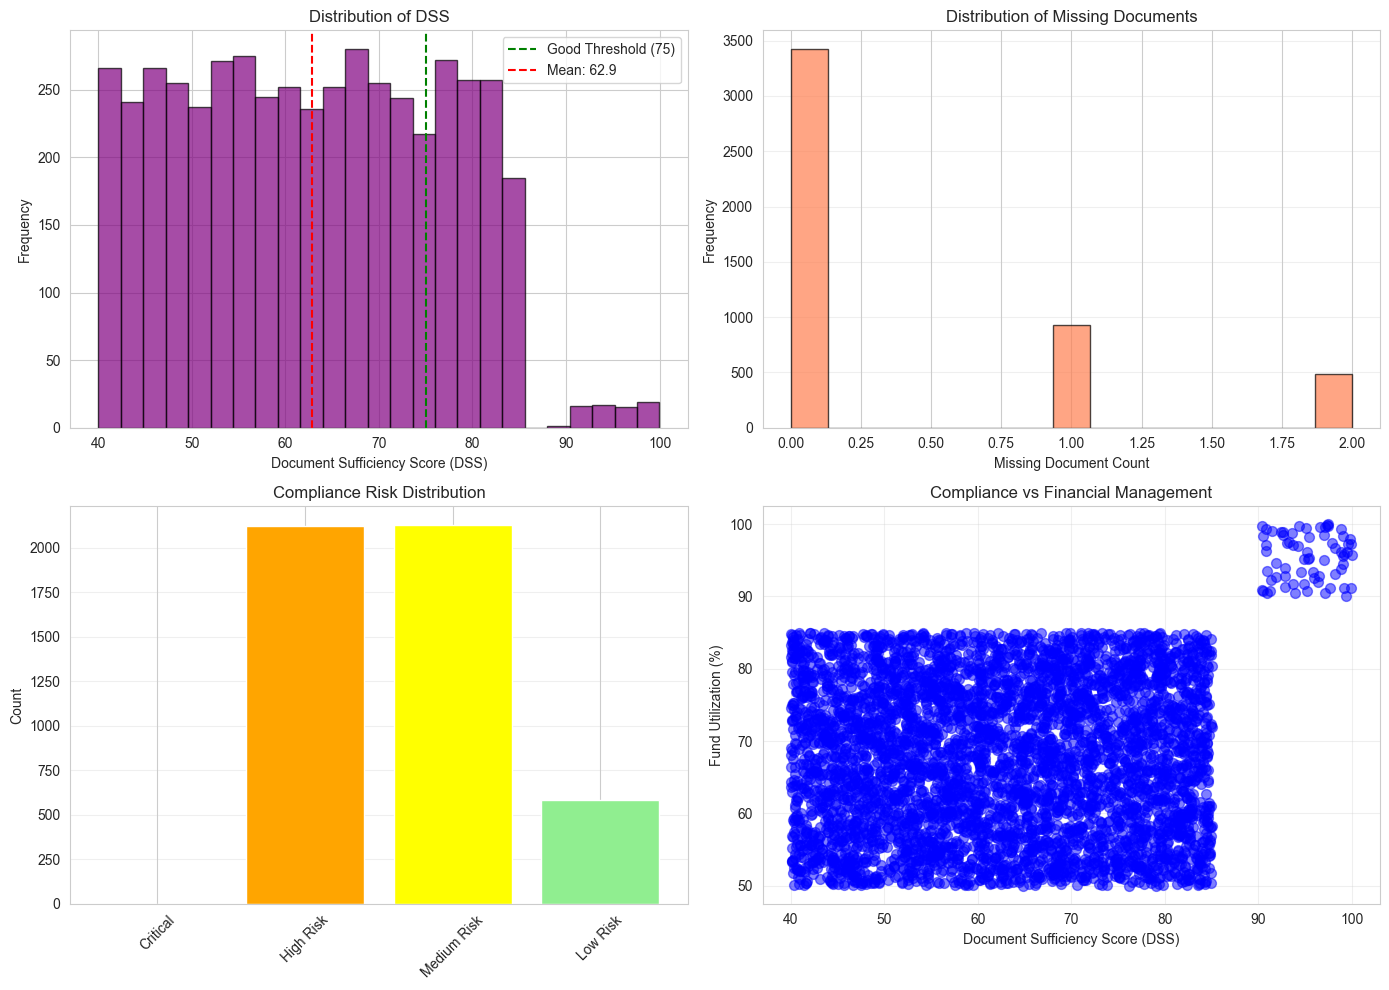

Compliance & Document Analysis:
  Mean DSS: 62.88
  Critical Risk (DSS < 40): 0 institutions
  High Risk (40-60): 2121 institutions
  Good Compliance (DSS ≥ 75): 1139 institutions
  Average Missing Documents: 0.39


In [8]:
# Analyze compliance and document management
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# DSS (Document Sufficiency Score) Distribution
axes[0, 0].hist(df_features['Avg_Doc_DSS'], bins=25, color='purple', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(75, color='green', linestyle='--', label='Good Threshold (75)')
axes[0, 0].axvline(df_features['Avg_Doc_DSS'].mean(), color='red', linestyle='--', 
                    label=f"Mean: {df_features['Avg_Doc_DSS'].mean():.1f}")
axes[0, 0].set_xlabel('Document Sufficiency Score (DSS)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of DSS')
axes[0, 0].legend()

# Missing Documents
axes[0, 1].hist(df_features['Missing_Doc_Count'], bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Missing Document Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Missing Documents')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Compliance Risk Categories
risk_categories = pd.cut(df_features['Avg_Doc_DSS'], 
                         bins=[0, 40, 60, 80, 100], 
                         labels=['Critical', 'High Risk', 'Medium Risk', 'Low Risk']).value_counts().sort_index()
colors_risk = ['darkred', 'orange', 'yellow', 'lightgreen']
axes[1, 0].bar(range(len(risk_categories)), risk_categories.values, color=colors_risk)
axes[1, 0].set_xticks(range(len(risk_categories)))
axes[1, 0].set_xticklabels(risk_categories.index, rotation=45)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Compliance Risk Distribution')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# DSS vs Fund Utilization
axes[1, 1].scatter(df_features['Avg_Doc_DSS'], df_features['Fund_Utilization'], alpha=0.5, s=50, color='blue')
axes[1, 1].set_xlabel('Document Sufficiency Score (DSS)')
axes[1, 1].set_ylabel('Fund Utilization (%)')
axes[1, 1].set_title('Compliance vs Financial Management')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Compliance & Document Analysis:")
print(f"  Mean DSS: {df_features['Avg_Doc_DSS'].mean():.2f}")
print(f"  Critical Risk (DSS < 40): {(df_features['Avg_Doc_DSS'] < 40).sum()} institutions")
print(f"  High Risk (40-60): {((df_features['Avg_Doc_DSS'] >= 40) & (df_features['Avg_Doc_DSS'] < 60)).sum()} institutions")
print(f"  Good Compliance (DSS ≥ 75): {(df_features['Avg_Doc_DSS'] >= 75).sum()} institutions")
print(f"  Average Missing Documents: {df_features['Missing_Doc_Count'].mean():.2f}")

# Overall Performance Score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution
axes[0, 0].hist(df_features['Overall_Performance_Score'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_features['Overall_Performance_Score'].mean(), color='red', linestyle='--', label=f"Mean: {df_features['Overall_Performance_Score'].mean():.1f}")
axes[0, 0].set_xlabel('Overall Performance Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall Performance Score Distribution')
axes[0, 0].legend()

# Performance categories
perf_categories = pd.cut(
    df_features['Overall_Performance_Score'],
    bins=[0, 40, 55, 70, 85, 100],
    labels=['Critical', 'Poor', 'Fair', 'Good', 'Excellent']
).value_counts().sort_index()

axes[0, 1].bar(range(len(perf_categories)), perf_categories.values, 
               color=['darkred', 'red', 'orange', 'lightgreen', 'green'])
axes[0, 1].set_xticklabels(perf_categories.index, rotation=45)
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Overall Performance Categories')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Feature importance
feature_cols = ['Placement_Rate', 'Faculty_Adequacy', 'Infrastructure_Quality', 
                'Fund_Utilization', 'Avg_Doc_DSS']
correlations = df_features[feature_cols + ['Overall_Performance_Score']].corr()['Overall_Performance_Score'][:-1].abs().sort_values(ascending=False)

axes[1, 0].barh(range(len(correlations)), correlations.values, color='steelblue')
axes[1, 0].set_yticks(range(len(correlations)))
axes[1, 0].set_yticklabels(correlations.index)
axes[1, 0].set_xlabel('Correlation with Overall Score')
axes[1, 0].set_title('Feature Importance (Correlation)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Top performers
top_performers = df_features.nlargest(10, 'Overall_Performance_Score')[['College Name', 'Overall_Performance_Score']]
axes[1, 1].barh(range(len(top_performers)), top_performers['Overall_Performance_Score'].values, color='green', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_performers)))
axes[1, 1].set_yticklabels([name[:20] for name in top_performers['College Name'].values], fontsize=8)
axes[1, 1].set_xlabel('Overall Performance Score')
axes[1, 1].set_title('Top 10 Performing Institutions')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nOverall Performance Insights:")
print(f"  Mean Score: {df_features['Overall_Performance_Score'].mean():.2f}")
print(f"  Median Score: {df_features['Overall_Performance_Score'].median():.2f}")
print(f"  Std Dev: {df_features['Overall_Performance_Score'].std():.2f}")